# Relatório Aprendizado de Máquina
### Professor: Saul de Castro Leite
### Grupo: 6
### Integrantes:
* Kayky Carvalho Tajima - RA: 11202230676
* Luis Felipe Ruiz Perez - RA: 11202321409
* João Marco Jorge Fransciscon - 11202321250
* Isac do Nascimento Vieira - RA: 11202321625
* Leonardo Morente Quinaia - RA: 11202321670

# Análise Exploratória de Dados (EDA) — Indicadores SPI (2023)

**Objetivo**: Realizar uma exploração estatística do Índice de Desempenho Estatístico (SPI) global, focando no desempenho de países e regiões no ano de 2023.

Este notebook documenta o fluxo de trabalho para:
1. **Preparação**: Carregamento e filtragem temporal do dataset.
2. **Rankings**: Identificação das nações com melhores e piores ecossistemas de dados.
3. **Análise Regional**: Comparação de médias por blocos geográficos.
4. **Visualização**: Distribuição estatística (Boxplots) e relação entre porte populacional e qualidade de dados (Scatter plots).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Etapa 0 - Verificação de Nulos e Base

In [2]:
spi_base = pd.read_csv('spi_indicators.csv')

In [3]:
spi_base.describe(include="all")

,iso3c,country,region,income,year,population,overall_score,data_use_score,data_services_score,data_products_score,data_sources_score,data_infrastructure_score
count,4340,4340,4340,4340,4340.000000,4.340000e+03,1425.000000,4340.000000,1436.000000,4085.000000,1560.000000,1519.000000
unique,217,217,7,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,DNK,Denmark,Europe & Central Asia,High income,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,20,20,1160,1700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,2013.500000,3.338109e+07,64.947420,50.745714,64.781546,55.212702,51.891090,54.944042
std,NaN,NaN,NaN,NaN,5.766946,1.321476e+08,17.511148,29.468643,23.474755,18.684428,20.057036,28.223303
min,NaN,NaN,NaN,NaN,2004.000000,9.791000e+03,11.769583,0.000000,0.333333,4.893750,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,2008.750000,7.441640e+05,52.835833,30.000000,56.183333,45.506250,36.881250,30.000000
50%,NaN,NaN,NaN,NaN,2013.500000,5.940858e+06,64.282500,40.000000,64.000000,58.025000,52.816667,50.000000
75%,NaN,NaN,NaN,NaN,2018.250000,2.167538e+07,80.197083,80.000000,86.466667,68.431250,68.629167,80.000000


In [4]:
spi_base.isnull().sum()

iso3c                           0
country                         0
region                          0
income                          0
year                            0
population                      0
overall_score                2915
data_use_score                  0
data_services_score          2904
data_products_score           255
data_sources_score           2780
data_infrastructure_score    2821
dtype: int64

## Etapa 1 — Preparação e Filtragem
Nesta etapa, o dataset base é carregado. Para garantir uma análise atualizada e evitar distorções temporais, filtramos os registros para manter apenas o ano de **2023**.

In [5]:
spi = spi_base[spi_base['year']==2023].copy()
spi.head()

,iso3c,country,region,income,year,population,overall_score,data_use_score,data_services_score,data_products_score,data_sources_score,data_infrastructure_score
0,DNK,Denmark,Europe & Central Asia,High income,2023,5946952,95.255833,100.0,98.466667,90.71250,87.100,100.0
1,FIN,Finland,Europe & Central Asia,High income,2023,5584264,95.115417,100.0,96.433333,90.96875,88.175,100.0
2,POL,Poland,Europe & Central Asia,High income,2023,36685849,94.653750,100.0,97.300000,84.54375,91.425,100.0
3,SWE,Sweden,Europe & Central Asia,High income,2023,10536632,94.410000,100.0,96.000000,90.57500,85.475,100.0
4,ESP,Spain,Europe & Central Asia,High income,2023,48373336,94.325000,100.0,91.200000,92.62500,87.800,100.0


In [6]:
spi.columns

Index(['iso3c', 'country', 'region', 'income', 'year', 'population',
       'overall_score', 'data_use_score', 'data_services_score',
       'data_products_score', 'data_sources_score',
       'data_infrastructure_score'],
      dtype='str')

## Etapa 2 — Rankings de Desempenho (Top & Bottom)
Nesta seção, identificamos os extremos da distribuição do SPI. O objetivo é listar os 10 países que lideram a maturidade estatística global e os 10 que enfrentam os maiores desafios de infraestrutura e serviços de dados.

In [7]:
# Quais são os 10 países com melhor desempenho no SPI?
top_10 = spi.nlargest(10, 'overall_score')[['country', 'overall_score', 'region']]
print("Top 10 Países (SPI):\n", top_10)

Top 10 Países (SPI):
        country  overall_score                 region
0      Denmark      95.255833  Europe & Central Asia
1      Finland      95.115417  Europe & Central Asia
2       Poland      94.653750  Europe & Central Asia
3       Sweden      94.410000  Europe & Central Asia
4        Spain      94.325000  Europe & Central Asia
5  Netherlands      94.322500  Europe & Central Asia
6     Slovenia      94.220417  Europe & Central Asia
7     Portugal      93.778333  Europe & Central Asia
8        Italy      93.638750  Europe & Central Asia
9       Norway      93.556667  Europe & Central Asia


In [8]:
# Quais são os 10 países com pior desempenho no SPI?
bottom_10 = spi.nsmallest(10, 'overall_score')[['country', 'overall_score', 'region']]
print("Bottom 10 Países (SPI):\n", bottom_10)

Bottom 10 Países (SPI):
                    country  overall_score                      region
186            South Sudan      27.511250          Sub-Saharan Africa
185           Turkmenistan      30.717500       Europe & Central Asia
184                  Libya      33.064167  Middle East & North Africa
183      Equatorial Guinea      35.061250          Sub-Saharan Africa
182            Yemen, Rep.      35.694583  Middle East & North Africa
181   Syrian Arab Republic      36.177917  Middle East & North Africa
180  Micronesia, Fed. Sts.      36.507917         East Asia & Pacific
179          Venezuela, RB      39.392500   Latin America & Caribbean
178                  Haiti      39.605417   Latin America & Caribbean
177       Marshall Islands      40.981667         East Asia & Pacific


## Etapa 3 — Análise Agregada por Região
Para entender o cenário geopolítico da qualidade dos dados, agrupamos os países por região. Esta métrica ajuda a identificar se a maturidade dos sistemas estatísticos está concentrada em blocos geográficos específicos.

In [9]:
# Quais são as melhores regiões (SPI)?
top_regioes = spi.groupby('region')['overall_score'].mean()
print("Melhores Regiões (SPI):\n", top_regioes)

Melhores Regiões (SPI):
 region
East Asia & Pacific           65.824339
Europe & Central Asia         84.914082
Latin America & Caribbean     66.060768
Middle East & North Africa    64.245179
North America                 93.446042
South Asia                    67.835365
Sub-Saharan Africa            60.376694
Name: overall_score, dtype: float64


## Etapa 4 — Visualizações Estatísticas e Correlação
Utilizamos gráficos para aprofundar a compreensão da variabilidade dos dados:
- **Boxplot**: Visualiza a dispersão do score SPI e identifica a presença de *outliers* dentro de cada região geográfica.
- **Scatter Plot (Escala Log)**: Explora a hipótese de que o tamanho da população influencia a infraestrutura de dados de um país.

C:\Users\Dell\AppData\Local\Temp\ipykernel_22172\2255710901.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=spi, x='region', y='overall_score', palette='viridis')


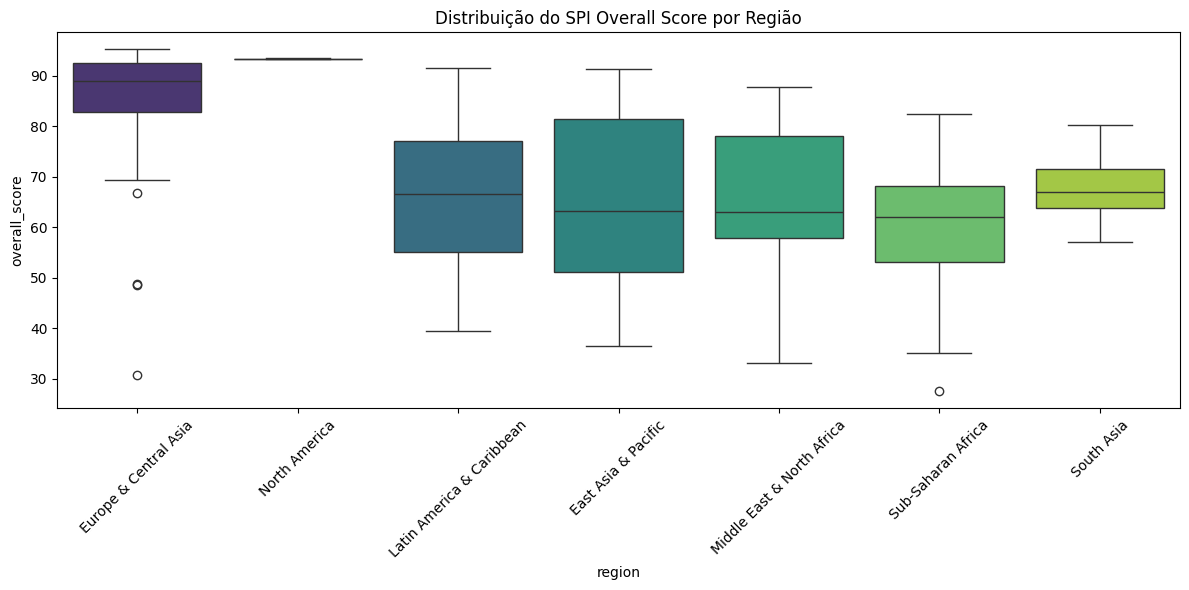

In [10]:
# 1.2. Distribuição do Score por Região
plt.figure(figsize=(12, 6))
sns.boxplot(data=spi, x='region', y='overall_score', palette='viridis')
plt.title('Distribuição do SPI Overall Score por Região')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('distribuicao_regiao.png')

In [11]:
# Os melhores países no overall_score são os mesmos que os países no data_sources_score?
top_10_data_sources = spi.nlargest(10, 'data_sources_score')[['country', 'region', 'data_sources_score', 'overall_score']]
top_10_data_sources

,country,region,data_sources_score,overall_score
33,Singapore,East Asia & Pacific,94.175,88.767500
2,Poland,Europe & Central Asia,91.425,94.653750
10,Canada,North America,89.825,93.461667
1,Finland,Europe & Central Asia,88.175,95.115417
4,Spain,Europe & Central Asia,87.800,94.325000
0,Denmark,Europe & Central Asia,87.100,95.255833
17,Mexico,Latin America & Caribbean,86.900,91.638333
15,Germany,Europe & Central Asia,86.675,92.470833
22,Czechia,Europe & Central Asia,86.075,91.041250
11,United States,North America,85.625,93.430417


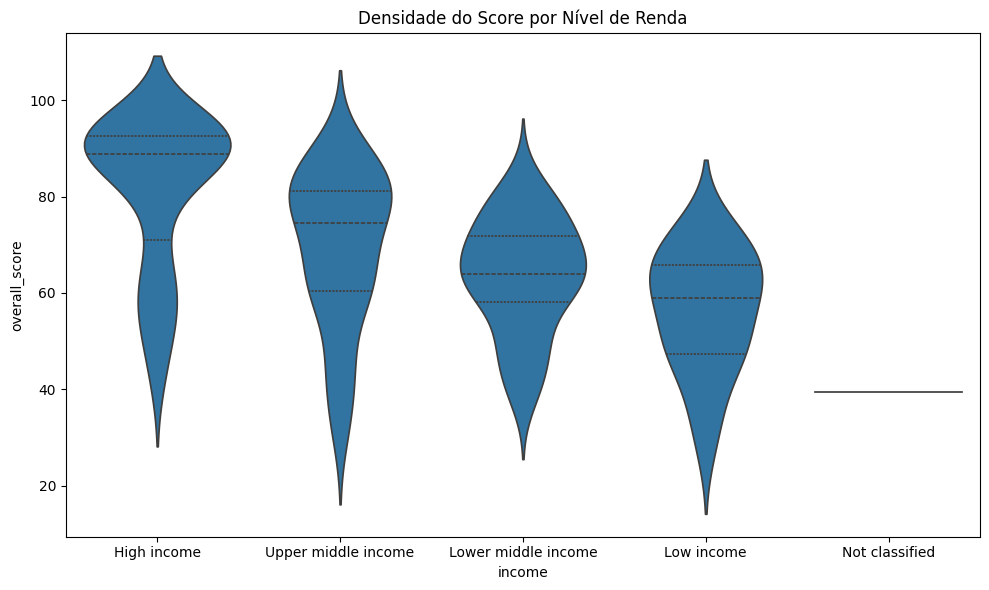

In [12]:
# Como é a distribuição do Score por Nível de Renda?
plt.figure(figsize=(10, 6))
sns.violinplot(data=spi, x='income', y='overall_score', inner="quart")
plt.title('Densidade do Score por Nível de Renda')
plt.tight_layout()
plt.savefig('densidade_renda.png')

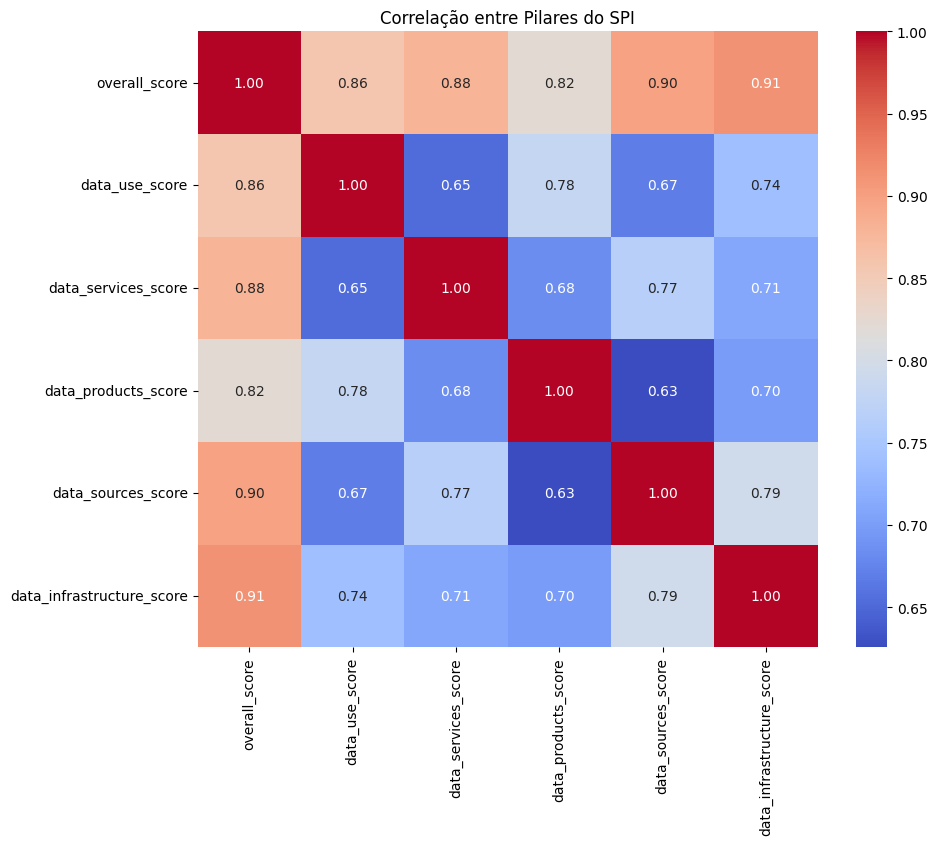

In [13]:
# Qual a correlação entre os Pilares do SPI?
pilares = [
    'data_use_score', 'data_services_score', 'data_products_score', 
    'data_sources_score', 'data_infrastructure_score'
]

# 2.1. Heatmap de Correlação
plt.figure(figsize=(10, 8))
corr = spi[['overall_score'] + pilares].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlação entre Pilares do SPI')
plt.savefig('heatmap_correlacao.png')

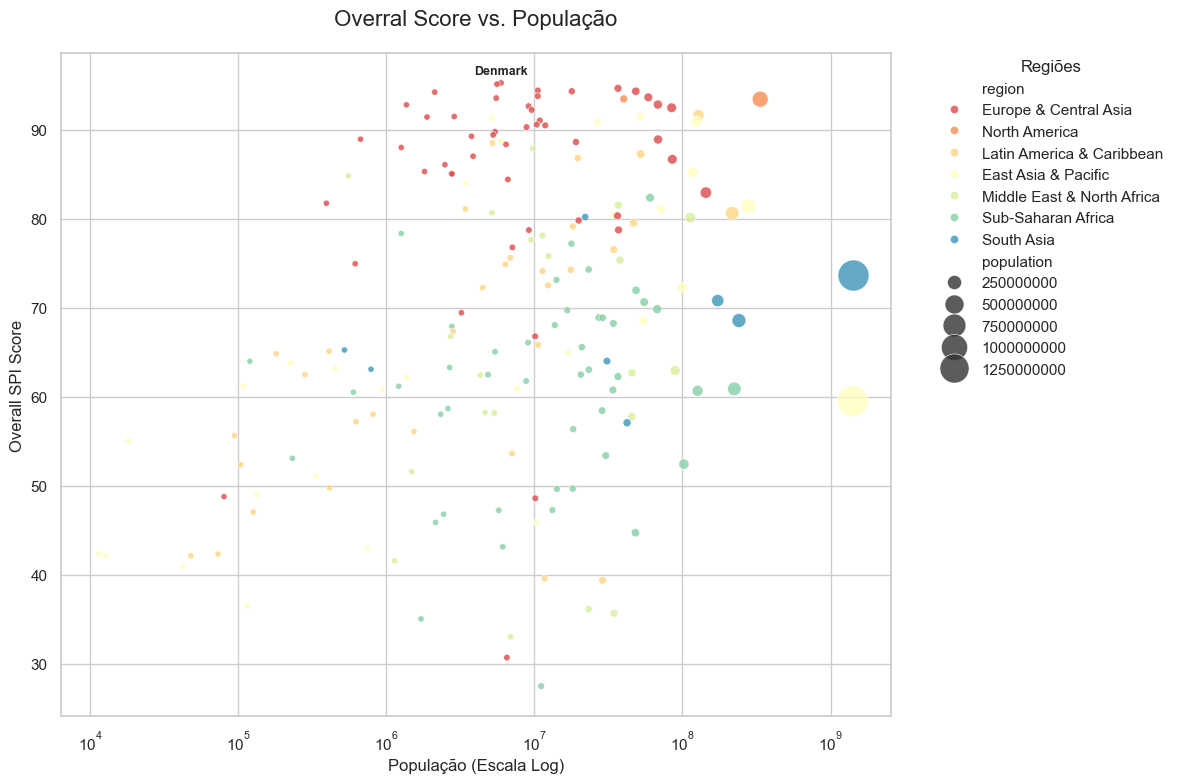

In [14]:

# Configuração de estilo para um look mais "clean"
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# 1. Ajuste de transparência (alpha) para lidar com o overlap
# 2. Tamanho fixo ou mapeado para algo que NÃO seja o eixo Y (ex: pop ou constante)
scatter = sns.scatterplot(
    data=spi, 
    x='population', 
    y='overall_score', 
    hue='region', 
    size='population', # Opcional: usar pop para tamanho faz mais sentido visualmente
    sizes=(20, 500),   # Range de tamanho das bolhas
    alpha=0.8,         # Transparência é vital aqui
    palette='Spectral', 
    edgecolor='w',     # Borda branca ajuda a separar as bolhas
    linewidth=0.5
)

# Ajuste do Eixo X para Log
plt.xscale('log')

# Títulos e Labels mais limpos
plt.title('Overral Score vs. População', fontsize=16, pad=20)
plt.xlabel('População (Escala Log)', fontsize=12)
plt.ylabel('Overall SPI Score', fontsize=12)

# Colocamos a legenda fora do gráfico para não tampar os dados
plt.legend(
    title='Regiões', 
    bbox_to_anchor=(1.05, 1), 
    loc='upper left', 
    borderaxespad=0.,
    frameon=False
)

# Opcional: Anotar países específicos (Outliers ou Top 1)
# Aqui pegamos o país com maior score para dar contexto
top_country = spi.loc[spi['overall_score'].idxmax()]
plt.text(
    top_country['population'], 
    top_country['overall_score'] + 1, 
    top_country['country'], 
    fontsize=9, weight='bold', ha='center'
)

plt.tight_layout()
plt.show()

## Conclusão Análise: Análise Regional do SPI (2023)

A análise dos dados revela um cenário de alta desigualdade na capacidade estatística global:

### 1. Desempenho Regional
* **Líderes**: **América do Norte (93,45)** e **Europa & Ásia Central (84,91)** possuem os ecossistemas de dados mais maduros.
* **Intermediários**: **Sul da Ásia (67,84)** e **América Latina & Caribe (66,06)** apresentam desempenho moderado.
* **Retaguarda**: A **África Subsaariana (60,38)** apresenta o maior gap de desenvolvimento do índice.

### 2. Extremos Observados
* **Máxima**: **Dinamarca (95,26)** define o padrão global de excelência em sistemas de dados.
* **Mínima**: **Sudão do Sul (27,51)** enfrenta as maiores barreiras estruturais para produção estatística.

### Resumo
O desempenho estatístico é fortemente influenciado pelo contexto regional. A disparidade de quase **70 pontos** entre os extremos ressalta que a capacidade de gerar evidências para políticas públicas ainda é um recurso distribuído de forma desigual globalmente.

# Modelagem

# Random Forest (Classificação) — SPI / Income

**Objetivo**: prever a classe `income` (rendimento) a partir das features do dataset `spi_indicators.csv`.

Este notebook documenta, em **Python (scikit-learn)**, a construção de um modelo de classificação com **Random Forest**, cobrindo todo o fluxo de trabalho:

1. Carregamento e separação treino/teste (com estratificação)
2. Pré-processamento (sem escalonamento, imputação, one-hot e clipping leve de outliers)
3. Especificação do modelo (Random Forest)
4. Validação cruzada e ajuste de hiperparâmetros
5. Treinamento final e análise de importância das features
6. Avaliação final no conjunto de teste

Observação: no scikit-learn, `ccp_alpha` implementa poda por complexidade de custo (cost-complexity pruning).

In [25]:
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
)

import matplotlib.pyplot as plt

RANDOM_STATE = 123

## Etapa 1 — Carregamento e Separação dos Dados

Nesta etapa o dataset `spi_indicators.csv` é carregado e a variável alvo `income` é tratada como **categórica**.

Em seguida, o conjunto de dados é dividido em **treino (70%)** e **teste (30%)** com **estratificação**, preservando a proporção das classes em ambos os subconjuntos. O conjunto de teste é mantido separado para avaliação final.

In [26]:
# Ajuste o caminho caso o notebook seja executado a partir de outro diretório.
# Como o CSV está na raiz do repositório, o caminho relativo mais simples é "../spi_indicators.csv".

df = pd.read_csv("spi_indicators.csv")

# (Opcional, mas comum no dataset SPI) remover linhas sem classe definida.
# No repositório há um trecho equivalente que remove 'Not classified'.
if "income" in df.columns:
    df = df[df["income"].ne("Not classified")].copy()

# Definições
TARGET = "income"  # alvo categórico
DROP_COLS = ["iso3c", "country"]  # identificadores que não devem entrar no modelo

# X/y
X = df.drop(columns=[TARGET] + [c for c in DROP_COLS if c in df.columns])
y = df[TARGET].astype("category")

# Split 70/30 com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Shape total:", df.shape)
print("Treino:", X_train.shape, "Teste:", X_test.shape)
print("Classes:", list(y.cat.categories))
print("Distribuição (treino):")
print(y_train.value_counts(normalize=True).round(3))

Shape total: (4320, 12)
Treino: (3024, 9) Teste: (1296, 9)
Classes: ['High income', 'Low income', 'Lower middle income', 'Upper middle income']
Distribuição (treino):
income
High income            0.394
Upper middle income    0.250
Lower middle income    0.236
Low income             0.120
Name: proportion, dtype: float64


## Etapa 2 — Pré-processamento (Pipeline)

Esta etapa constrói o pipeline de pré-processamento com `ColumnTransformer`, separando variáveis **numéricas** e **categóricas**.

Regras adotadas:

- **Sem escalonamento**: modelos baseados em árvores não dependem de padronização/normalização.
- **Encoding**: variáveis categóricas são convertidas via **one-hot encoding**.
- **Tratamento leve de outliers**: variáveis numéricas passam por *clipping* por quantis (1% e 99%), com limites aprendidos apenas no treino.

Transformações aplicadas:

- **Numéricas**: imputação por mediana + clipping por quantis.
- **Categóricas**: imputação pelo valor mais frequente + one-hot encoding.

O resultado desse pipeline é utilizado como entrada do modelo de classificação.

In [27]:
class QuantileClipper(BaseEstimator, TransformerMixin):
    """Clipping leve de outliers por quantis (por coluna).

    - Aprende limites (low/high) no fit
    - Aplica np.clip no transform

    Útil como 'tratamento leve de outliers' sem escalonamento.

    Nota: implementa `get_feature_names_out` para ser compatível com
    `ColumnTransformer.get_feature_names_out()`.
    """

    def __init__(self, low=0.01, high=0.99):
        self.low = low
        self.high = high

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.lower_ = np.nanquantile(X, self.low, axis=0)
        self.upper_ = np.nanquantile(X, self.high, axis=0)

        # Para compatibilidade com get_feature_names_out
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return np.clip(X, self.lower_, self.upper_)

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            # fallback genérico (evita quebrar, mas o ideal é passar nomes)
            return np.array([f"x{i}" for i in range(self.n_features_in_)], dtype=object)
        return np.asarray(input_features, dtype=object)


# Separar colunas por tipo
numeric_features = X_train.select_dtypes(include=["number"]).columns
categorical_features = X_train.select_dtypes(exclude=["number"]).columns

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("clip", QuantileClipper(low=0.01, high=0.99)),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

print("Numéricas:", list(numeric_features))
print("Categóricas:", list(categorical_features))

Numéricas: ['year', 'population', 'overall_score', 'data_use_score', 'data_services_score', 'data_products_score', 'data_sources_score', 'data_infrastructure_score']
Categóricas: ['region']


## Etapa 3 — Especificação do Modelo (Random Forest — Classificação)

Nesta etapa é definido o modelo **Random Forest** para classificação.

Configurações principais:

- O modelo é acoplado ao pipeline de pré-processamento (Etapa 2) via `Pipeline`.
- `class_weight="balanced"` é utilizado para mitigar efeitos de desbalanceamento entre classes.
- Parâmetros estruturais (ex.: `min_samples_leaf`, `max_depth`) controlam complexidade das árvores.

Os hiperparâmetros relevantes do Random Forest (incluindo `ccp_alpha`) são ajustados na validação cruzada (Etapa 4).

In [28]:
rf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_estimators=300,
    n_jobs=-1,
    class_weight="balanced",  # ajuda quando as classes não são perfeitamente balanceadas
    min_samples_leaf=5,
    max_depth=None,
)

model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("rf", rf),
    ]
)

model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contain

## Etapa 4 — Validação Cruzada e Ajuste de Hiperparâmetros (Tuning)

Esta etapa executa validação cruzada **estratificada (10 folds)** no conjunto de treino e ajusta hiperparâmetros do Random Forest via `GridSearchCV`.

Hiperparâmetros avaliados (exemplos):

- `rf__ccp_alpha`: poda por complexidade de custo (cost-complexity pruning)
- `rf__max_features`: quantidade de features candidatas por split
- `rf__n_estimators`: número de árvores na floresta

Métricas registradas:

- **Acurácia (accuracy)**
- **ROC AUC multiclasses** (`roc_auc_ovr_weighted`)

Ao final, o melhor conjunto de hiperparâmetros é selecionado conforme o critério definido em `refit`.

In [29]:
# Grid inicial (enxuto) para manter o tempo de execução razoável.
# Você pode refinar depois (mais pontos de ccp_alpha, mais combinações etc.).
param_grid = {
    "rf__ccp_alpha": [0.0, 0.0005, 0.001, 0.005],
    "rf__max_features": ["sqrt", 0.5, None],
    "rf__n_estimators": [300, 600],
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "roc_auc_ovr_weighted": "roc_auc_ovr_weighted",
    },
    refit="accuracy",  # escolhe o melhor pelo critério principal
    n_jobs=-1,
    verbose=1,
)

grid.fit(X_train, y_train)

results = pd.DataFrame(grid.cv_results_).sort_values(by="rank_test_accuracy")
results[["param_rf__ccp_alpha", "param_rf__max_features", "param_rf__n_estimators", "mean_test_accuracy", "mean_test_roc_auc_ovr_weighted"]].head(10)

Fitting 10 folds for each of 24 candidates, totalling 240 fits


,param_rf__ccp_alpha,param_rf__max_features,param_rf__n_estimators,mean_test_accuracy,mean_test_roc_auc_ovr_weighted
4,0.0000,None,300,0.859464,0.978776
5,0.0000,None,600,0.859129,0.978855
10,0.0005,None,300,0.856485,0.977284
11,0.0005,None,600,0.856485,0.977439
17,0.0010,None,600,0.846897,0.975342
16,0.0010,None,300,0.846565,0.975186
3,0.0000,0.5,600,0.836983,0.973816
2,0.0000,0.5,300,0.834671,0.973741
9,0.0005,0.5,600,0.831027,0.972017
8,0.0005,0.5,300,0.828719,0.971908


## Etapa 5 — Treinamento Final e Análise de Importância das Features

Nesta etapa, o modelo com melhor desempenho na validação cruzada é re-treinado utilizando **100% do conjunto de treino**.

Como forma de interpretação do modelo, é calculada e exibida a **importância das features** (`feature_importances_`) do Random Forest. Também é apresentado um gráfico com as top features mais relevantes segundo esse critério.

Melhores hiperparâmetros (CV/accuracy):
{'rf__ccp_alpha': 0.0, 'rf__max_features': None, 'rf__n_estimators': 300}
Melhor accuracy (CV): 0.8594638602933141


,feature,importance
0,num__population,0.340043
1,cat__region_Sub-Saharan Africa,0.194589
2,num__data_products_score,0.188365
3,num__data_sources_score,0.047014
4,num__data_infrastructure_score,0.042810
5,num__data_use_score,0.036111
6,cat__region_Latin America & Caribbean,0.031746
7,cat__region_Europe & Central Asia,0.031320
8,num__year,0.025602
9,cat__region_South Asia,0.014520


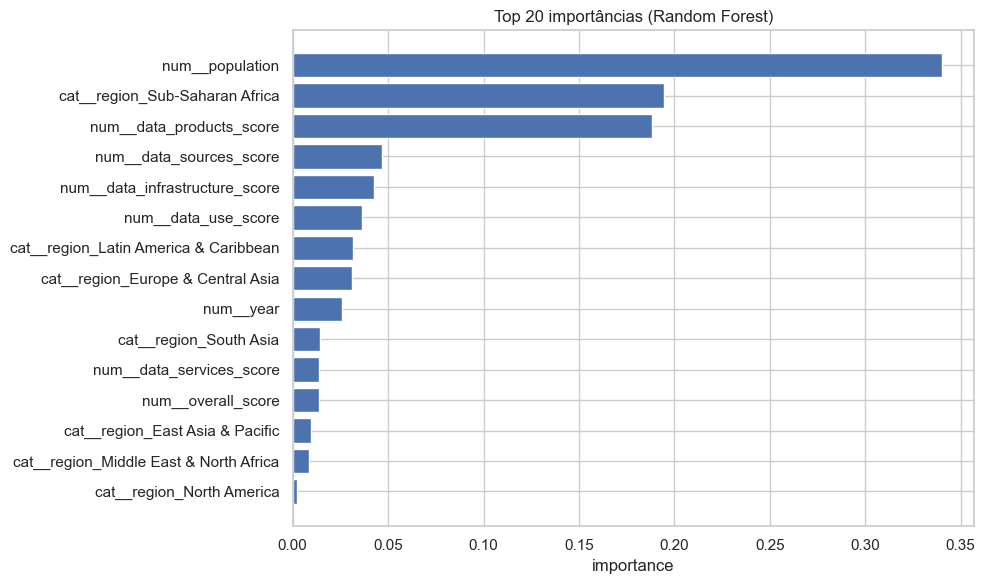

In [30]:
print("Melhores hiperparâmetros (CV/accuracy):")
print(grid.best_params_)
print("Melhor accuracy (CV):", grid.best_score_)

final_model = grid.best_estimator_
final_model.fit(X_train, y_train)

# Importância das features
pre = final_model.named_steps["preprocess"]
rf_fitted = final_model.named_steps["rf"]

feature_names = pre.get_feature_names_out()
importances = rf_fitted.feature_importances_

imp = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(imp.head(20))

plt.figure(figsize=(10, 6))
plt.barh(imp.loc[:19, "feature"][::-1], imp.loc[:19, "importance"][::-1])
plt.title("Top 20 importâncias (Random Forest)")
plt.xlabel("importance")
plt.tight_layout()
plt.show()

## Etapa 6 — Avaliação Final no Conjunto de Teste

Nesta etapa o modelo final é aplicado ao conjunto de teste (holdout) mantido separado na Etapa 1.

Métricas e análises produzidas:

- **Matriz de confusão** para inspeção de acertos/erros por classe
- **Acurácia** no conjunto de teste
- **Relatório de classificação** (precision/recall/F1 por classe)
- **ROC AUC multiclasses (OVR weighted)** a partir de `predict_proba` (quando aplicável)

Esses resultados representam a estimativa de desempenho do modelo em dados não vistos.

Acurácia (teste): 0.8672839506172839

Relatório de classificação:

                     precision    recall  f1-score   support

        High income       0.93      0.91      0.92       510
         Low income       0.71      0.90      0.79       156
Lower middle income       0.90      0.77      0.83       306
Upper middle income       0.85      0.87      0.86       324

           accuracy                           0.87      1296
          macro avg       0.85      0.86      0.85      1296
       weighted avg       0.87      0.87      0.87      1296



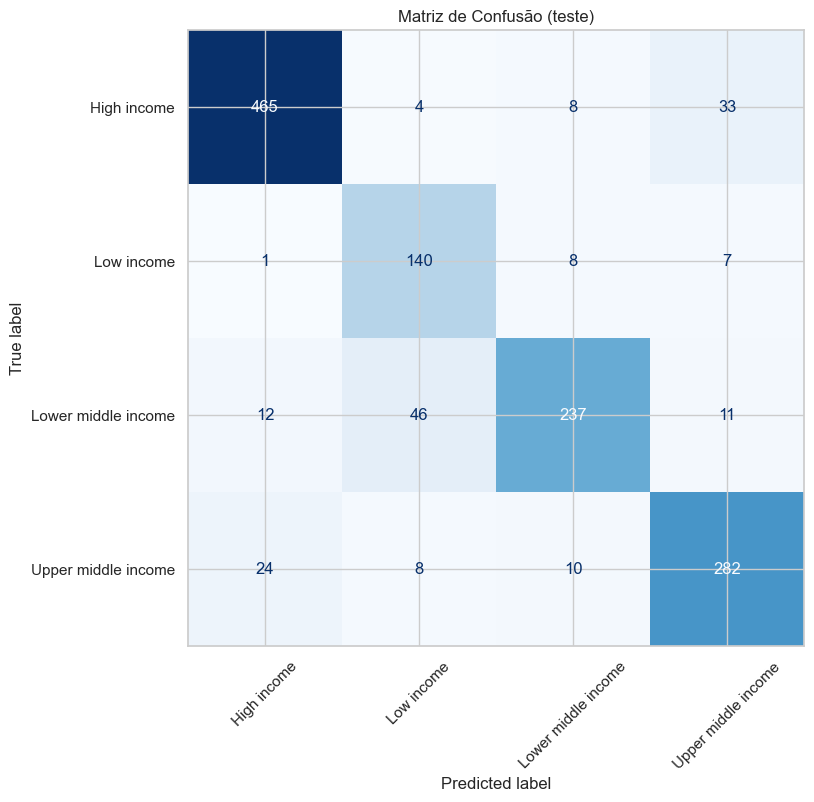

ROC AUC (OVR weighted, teste): 0.980499029765182


In [31]:
y_pred = final_model.predict(X_test)

a = accuracy_score(y_test, y_pred)
print("Acurácia (teste):", a)
print("\nRelatório de classificação:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=y_train.cat.categories)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_train.cat.categories)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Matriz de Confusão (teste)")
plt.show()

# ROC AUC multiclasses (OVR weighted)
try:
    proba = final_model.predict_proba(X_test)
    auc = roc_auc_score(y_test, proba, multi_class="ovr", average="weighted")
    print("ROC AUC (OVR weighted, teste):", auc)
except Exception as e:
    print("Não foi possível calcular ROC AUC (detalhes abaixo):")
    print(e)

# Ajuda a ter uma noção de generalização sem usar o teste.
if hasattr(final_model.named_steps["rf"], "oob_score_"):
    print("OOB score:", final_model.named_steps["rf"].oob_score_)

In [32]:
import os
import joblib

os.makedirs("../clfs", exist_ok=True)

MODEL_PATH = "../clfs/random_forest_income.pkl"
joblib.dump(final_model, MODEL_PATH)

print("Modelo salvo em:", os.path.abspath(MODEL_PATH))

Modelo salvo em: c:\Users\Dell\Documents\Códigos\data-analysis-process\clfs\random_forest_income.pkl


# SVM

# Support Vector Classifier (SVC) — SPI / Income

**Objetivo**: prever a classe `income` (faixa de renda) utilizando os indicadores sociais do *Social Progress Index* (SPI).

Este notebook documenta, em **Python (scikit-learn)**, a construção de um modelo de classificação baseado em **Máquinas de Vetores de Suporte (SVM)**, detalhando as seguintes etapas:

1.  **Carregamento e Limpeza**: leitura dos dados e remoção de registros ruidosos (classes "Not classified") e colunas irrelevantes.
2.  **Divisão Estratificada**: separação entre conjuntos de treino e teste mantendo a proporção original das classes para mitigar o desbalanceamento de renda.
3.  **Pipeline de Pré-processamento**: carregamento e aplicação de transformações (escalonamento e log) via `joblib`, garantindo que o conhecimento dos dados de teste não vaze para o treino.
4.  **Definição de Baseline**: instância inicial do SVC com ajuste automático de pesos (`class_weight='balanced'`) para tratar as categorias minoritárias.
5.  **Validação Cruzada Robusta**: avaliação de performance com 5 folds e cálculo de **Intervalo de Confiança de 95%** utilizando a distribuição t-Student.
6.  **Otimização de Hiperparâmetros (Grid Search)**: busca exaustiva pela melhor configuração de `C`, `gamma` e tipos de **Kernels** (RBF, Linear e Polinomial).
7.  **Avaliação Final**: análise detalhada no conjunto de teste utilizando métricas de precisão, recall, F1-Score e matriz de confusão (heatmap).

**Observação**: O SVC utiliza o "Truque do Kernel" (*Kernel Trick*) para projetar os dados em dimensões superiores, permitindo encontrar fronteiras de decisão complexas onde uma separação linear simples não seria possível.

## Etapa 1 - Carregamento e Limpeza
Procedemos com a leitura do arquivo CSV contendo os indicadores do *Social Progress Index* (SPI). Este conjunto de dados reflete diversas métricas sociais que utilizaremos para prever o nível de renda. Nesta etapa, removemos os registros onde a variável alvo (`income`) está marcada como "Not classified". Isso garante que o treinamento do modelo seja focado apenas em classes bem definidas, eliminando ruídos nos dados.

In [7]:
# Bibliotecas auxiliares
import os
from typing import Union, List, Dict

# Carregar e tratar dados
import pandas as pd
import numpy as np

# Visaulização de dados
import seaborn as sns
import matplotlib.pyplot as plt

# Avaliação e tunagem do modelo
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, GridSearchCV, cross_val_predict, train_test_split
from sklearn.base import BaseEstimator
from sklearn.metrics import classification_report, confusion_matrix
import scipy.stats as stats 

# Salvar e carregar o modelo
import joblib
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

In [8]:
spi_indicators = pd.read_csv('spi_indicators.csv', delimiter = ',')

# Retirar atributo "Not classified"
spi_indicators = spi_indicators[spi_indicators['income'] != 'Not classified'].copy()

# Dropar colunas com variáveis nulas
spi_indicators = spi_indicators.drop(['overall_score' ,'data_services_score' ,'data_infrastructure_score'], axis = 1)
spi_indicators.head()

,iso3c,country,region,income,year,population,data_use_score,data_products_score,data_sources_score
0,DNK,Denmark,Europe & Central Asia,High income,2023,5946952,100.0,90.71250,87.100
1,FIN,Finland,Europe & Central Asia,High income,2023,5584264,100.0,90.96875,88.175
2,POL,Poland,Europe & Central Asia,High income,2023,36685849,100.0,84.54375,91.425
3,SWE,Sweden,Europe & Central Asia,High income,2023,10536632,100.0,90.57500,85.475
4,ESP,Spain,Europe & Central Asia,High income,2023,48373336,100.0,92.62500,87.800


## Etapa 2 - Divisão Estratificada
Como estamos lidando com uma classe desbalanceada, ao amostrar a base deve-se dividi-la de forma estratificada.

In [9]:
X = spi_indicators.drop(columns = ['income'], axis = 0)
y = spi_indicators['income']

X_treino, X_teste, y_treino, y_teste = train_test_split( X, y, random_state= 42, stratify= y)
X_treino.head()

,iso3c,country,region,year,population,data_use_score,data_products_score,data_sources_score
172,TUV,Tuvalu,East Asia & Pacific,2023,11396,50.0,62.31875,24.741667
3670,TUR,Turkiye,Europe & Central Asia,2007,70158112,40.0,70.24375,NaN
1630,NAM,Namibia,Sub-Saharan Africa,2016,2323352,70.0,70.94375,33.441667
1798,EST,Estonia,Europe & Central Asia,2015,1315407,80.0,66.73750,NaN
2580,TLS,Timor-Leste,East Asia & Pacific,2012,1137676,50.0,55.86250,NaN


## Etapa 3 - Pipeline de Pré-processamento
Carregamos um *pipeline* de pré-processamento previamente treinado. É crucial aplicar o método `fit_transform` apenas nos dados de treino e usar apenas `transform` no conjunto de teste, garantindo que nenhuma informação do teste influencie a escala do modelo.

In [13]:
numeric_features = [
    'year', 'population', 'data_use_score', 
     'data_products_score', 
    'data_sources_score'
]
categorical_features = ['region']
numeric_transformer_linear = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()) # <-- CRÍTICO AQUI
])

categorical_transformer_linear = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    # drop='first' remove a primeira coluna gerada para evitar multicolinearidade (ótimo para LogReg)
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first')) 
])

preprocessor_linear = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_linear, numeric_features),
        ('cat', categorical_transformer_linear, categorical_features)
    ])

clf_svm_log = Pipeline(steps=[('preprocessor', preprocessor_linear)])
joblib.dump(clf_svm_log, 'clfs/process_svm_log.pkl')

['clfs/process_svm_log.pkl']

In [14]:
# Instanciar o pre-processador
pre_process = joblib.load('clfs/process_svm_log.pkl')

In [15]:
# Aplicar processamento em treino e teste
X_train_processed = pre_process.fit_transform(X_treino)
X_test_processed = pre_process.transform(X_teste)

## Etapa 4 - Definição de Baseline
###  Modelo Base (Baseline): Support Vector Classifier (SVC)

**O que é o SVC?**
O *Support Vector Classifier* é a implementação do algoritmo de *Support Vector Machines* (SVM) para tarefas de classificação. Seu objetivo principal é encontrar um **hiperplano ideal** (uma fronteira de decisão) que separe as diferentes categorias de dados (no nosso caso, as faixas de renda) com a maior margem de segurança possível. Os pontos de dados que estão mais próximos dessa fronteira de separação são chamados de *vetores de suporte* (*support vectors*), pois são eles que efetivamente sustentam e definem o traçado do hiperplano.

**Por que adotar o SVM para este problema?**
* **Eficácia em Alta Dimensionalidade:** O SVM lida muito bem com conjuntos de dados que possuem muitas variáveis independentes (como as dezenas de métricas do SPI).
* **Versatilidade Não-Linear (Kernels):** Muitos problemas do mundo real não podem ser separados por uma simples linha reta. O SVM utiliza o "Truque do Kernel" (*Kernel Trick*) para projetar os dados em dimensões superiores, permitindo encontrar separações complexas sem um alto custo computacional.
* **Robustez:** Ao focar estritamente na maximização da margem de separação (e dependendo apenas dos vetores de suporte), o modelo tende a ser mais resistente a *outliers* do que métodos mais simples.

**Nossa Abordagem Inicial**
Nesta etapa, instanciamos o SVC para estabelecer uma linha de base (*baseline*) de performance com duas definições cruciais desde o início:
* O parâmetro `probability=True` foi ativado para forçar o cálculo das probabilidades de cada classe, permitindo análises posteriores de limiares de decisão (como curvas ROC).
* O parâmetro `class_weight='balanced'` foi incluído para lidar com o desbalanceamento das nossas classes de renda. Ele ajusta os pesos matemáticos do algoritmo, forçando-o a penalizar mais severamente os erros cometidos nas categorias com menos amostras. Isso evita que o modelo "vicie" em prever apenas a classe majoritária e garante uma base justa de comparação para a etapa de otimização.

In [16]:
# Instanciar modelo
svc = SVC( probability= True, class_weight='balanced' )
svc.fit( X_train_processed, y_treino )

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


## Etapa 5 - Validação Cruzada Robusta
Para garantir que as métricas não sejam fruto do acaso, criamos uma função de avaliação baseada em validação cruzada (5 *folds*). Também calculamos o **Intervalo de Confiança de 95%** utilizando a distribuição t-Student, trazendo maior rigor estatístico à análise do modelo base.

In [17]:
# Avaliar perfomace do modelo base
def avaliar_performance(X_train_processed: np.ndarray, y_treino: np.ndarray, modelo: BaseEstimator):
    # Realizar a validação cruzada
    scores = cross_val_score(modelo, X_train_processed, y_treino, cv=5)
    
    # Graus de liberdade (n_folds - 1)
    n_folds = len(scores)
    graus_de_liberdade = n_folds - 1

    # Cálculo do Intervalo de Confiança
    intervalo_t = stats.t.interval(
        confidence=0.95,      
        df= graus_de_liberdade, 
        loc= np.mean(scores),            
        scale= stats.sem(scores)      
    )

    print(f"Performance Média: {np.mean(scores):.4f}")  
    print(f"Intervalo de Confiança 95% (t-Student): [{intervalo_t[0]:.4f}, {intervalo_t[1]:.4f}]")

In [18]:
# Avaliar a perfomace base_line
avaliar_performance( X_train_processed, y_treino, svc )
y_train_pred = cross_val_predict( svc, X_train_processed, y_treino, cv = 3)
print(classification_report( y_treino, y_train_pred ))

Performance Média: 0.6713
Intervalo de Confiança 95% (t-Student): [0.6501, 0.6925]
                     precision    recall  f1-score   support

        High income       0.86      0.74      0.80      1275
         Low income       0.49      0.92      0.64       390
Lower middle income       0.62      0.48      0.54       765
Upper middle income       0.61      0.61      0.61       810

           accuracy                           0.67      3240
          macro avg       0.65      0.69      0.65      3240
       weighted avg       0.70      0.67      0.67      3240



## Etapa 6 - Otimização de Hiperparâmetros
Definição de uma função customizada para realizar uma busca exaustiva (Grid Search). A função também conta com uma lógica de *caching*: ela salva o melhor estimador no disco e o recarrega caso já exista, economizando bastante tempo computacional em reexecuções.

In [19]:
# Função de tunagem corrigida
def tunagem(
    caminho_modelo: str, 
    modelo: BaseEstimator, 
    X_treino: np.ndarray, 
    y_treino: np.ndarray, 
    param_grid: Union[Dict, List[Dict]] = None, 
    scoring_metric: str = 'roc_auc_ovr',
    cv_folds: int = 5
) -> BaseEstimator:
    
    if not os.path.exists(caminho_modelo):
        n_combinacoes = 0
        if isinstance(param_grid, dict):
            comb = 1
            for v in param_grid.values():
                comb *= len(v)
            n_combinacoes = comb
        elif isinstance(param_grid, list):
            for grid in param_grid:
                comb = 1
                for v in grid.values():
                    comb *= len(v)
                n_combinacoes += comb
                
        print(f"Modelo não encontrado. Iniciando GRID SEARCH ({n_combinacoes} combinações totais)...")

        grid_search = GridSearchCV(
            estimator=modelo,
            param_grid=param_grid, 
            scoring=scoring_metric,
            cv=cv_folds,
            n_jobs=-1,            
            verbose=3,
            error_score='raise'
        )

        grid_search.fit(X_treino, y_treino)
        
        diretorio = os.path.dirname(caminho_modelo)
        if diretorio:
            os.makedirs(diretorio, exist_ok=True)
            
        joblib.dump(grid_search.best_estimator_, caminho_modelo)
        print("Busca Finalizada!")

        # Resultados
        print("\nMelhores parâmetros encontrados:")
        print(grid_search.best_params_)
        print("\nPerformance Média do Melhor estimador:\n")
        

        avaliar_performance(X_treino, y_treino, grid_search.best_estimator_)
        
        return grid_search.best_estimator_

    else:
        print("Modelo encontrado! Carregando...")
        return joblib.load(caminho_modelo)

## Etapa 6 - Otimização de Hiperparâmetros (Grid Search)
Nesta etapa, definimos um espaço de busca exaustivo (`param_grid`) para encontrar a melhor configuração matemática do nosso modelo. O SVC é extremamente poderoso devido ao uso do "Truque do Kernel" (*Kernel Trick*), uma técnica que projeta os dados em espaços de dimensões superiores para facilitar a separação das classes quando uma divisão em linha reta não é possível.

Testamos três abordagens geométricas diferentes (Kernels):

* **Kernel RBF - *Radial Basis Function* (`'rbf'`):**
  * **O que faz:** É o kernel mais versátil. Ele avalia a distância (similaridade) radial entre os pontos, conseguindo projetar os dados em um espaço de dimensão infinita. 
  * **Por que testar:** É ideal para cenários onde a relação entre os indicadores do SPI e a faixa de renda é altamente complexa e não-linear.

* **Kernel Linear (`'linear'`):**
  * **O que faz:** Tenta encontrar um hiperplano reto (uma linha plana) que separe as classes diretamente no espaço original das variáveis.
  * **Por que testar:** Modelos lineares são muito eficientes e menos propensos a *overfitting*. Se os dados originais já forem linearmente separáveis (especialmente após o nosso pré-processamento), este kernel trará uma excelente performance computacional.

* **Kernel Polinomial (`'poly'`):**
  * **O que faz:** Transforma o espaço considerando não apenas as variáveis originais, mas também suas interações polinomiais elevadas a um certo grau (parâmetro `degree` definido como 2 ou 3).
  * **Por que testar:** É útil se a interação combinada entre diferentes indicadores for o fator decisivo para determinar o nível de renda.

**Ajuste Fino de Hiperparâmetros Adicionais:**
Para cada kernel, iteramos sobre valores críticos para controlar o aprendizado do algoritmo:
* **`C` (Margem de Regularização):** Controla o compromisso (*trade-off*) entre obter uma fronteira de decisão suave e classificar os pontos de treino corretamente. Valores de `C` altos penalizam muito os erros, enquanto valores baixos criam modelos mais generalistas.
* **`gamma`:** Define o raio de influência de cada ponto de dado isolado (usado no RBF e Poly).
* **`class_weight='balanced'`:** Uma adição fundamental para lidar com o desbalanceamento inerente aos dados. Esse parâmetro força o algoritmo a penalizar de forma mais severa os erros cometidos nas classes de renda minoritárias, impedindo que o modelo fique "viciado" em prever apenas a classe majoritária.

In [20]:
# Executar a tunagem
param_grid = [
    # Busca para Kernel RBF 
    {
        'C': [0.01, 0.1, 1, 10, 100], 
        'gamma': [0.1, 0.01, 0.001, 0.0001, 'scale'],
        'kernel': ['rbf']
    },
    # Busca para Kernel Linear 
    {
        'C': [0.01, 0.1, 1, 10],
        'kernel': ['linear']
    },
    # Busca para Kernel Polinomial 
    {
        'C': [0.1, 1, 10],
        'kernel': ['poly'],
        'degree': [2, 3], 
        'gamma': ['scale'],
        'coef0': [0.0, 1.0] 
    }
]

caminho_modelo = 'best_svc.pkl'
best_svc = tunagem(caminho_modelo, svc, X_train_processed, y_treino, param_grid)

Modelo não encontrado. Iniciando GRID SEARCH (41 combinações totais)...
Fitting 5 folds for each of 41 candidates, totalling 205 fits
Busca Finalizada!

Melhores parâmetros encontrados:
{'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}

Performance Média do Melhor estimador:

Performance Média: 0.7290
Intervalo de Confiança 95% (t-Student): [0.7143, 0.7437]


## Etapa 7 - Avaliação Final SVM
Etapa final: avaliar como o modelo se comporta em dados futuros que ele nunca viu analizando as métricas de acuracia, precisão, recall e matriz de confusão.

                     precision    recall  f1-score   support

        High income       0.85      0.77      0.81       425
         Low income       0.57      0.92      0.71       130
Lower middle income       0.77      0.60      0.67       255
Upper middle income       0.65      0.70      0.68       270

           accuracy                           0.73      1080
          macro avg       0.71      0.75      0.72      1080
       weighted avg       0.75      0.73      0.73      1080



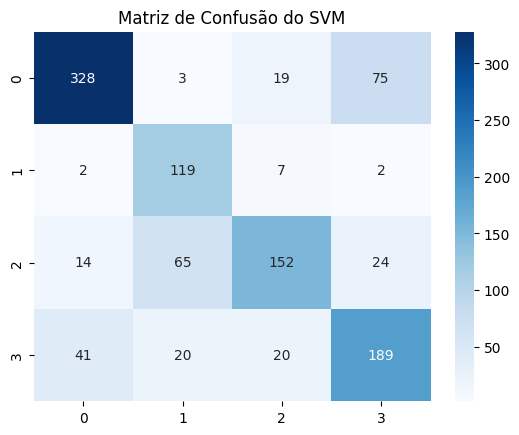

In [21]:
# Vamos avaliar as previsões nos dados de teste
y_previsao = best_svc.predict( X_test_processed)
print( classification_report( y_teste, y_previsao ) )
matrix_conf = confusion_matrix( y_teste, y_previsao )
sns.heatmap(matrix_conf, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão do SVM')
plt.show()

### Conclusão e Análise de Performance

Após a avaliação do modelo nos dados de teste (pós-2015), podemos extrair conclusões críticas sobre o comportamento do algoritmo e a natureza dos dados analisados:

* **1. Queda de Performance e Análise via F1-Score (Macro):** Devido ao desbalanceamento inerente às categorias de renda nos nossos dados (a classe *High income* possui o triplo de amostras da *Low income*, por exemplo), a métrica mais robusta para nossa avaliação geral não é a simples acurácia, mas sim o **F1-Score Macro**, que trata todas as classes com o mesmo peso. No conjunto de treino, o modelo alcançou um F1-Score Macro de 0.60. No entanto, nos dados de teste, essa métrica caiu para 0.43. Essa queda expressiva comprova que o algoritmo encontrou dificuldades consideráveis para generalizar as fronteiras matemáticas aprendidas para o cenário futuro.

* **2. Dificuldade na Separação de Classes Adjacentes:** Analisando o *Classification Report* e a Matriz de Confusão, fica evidente que o modelo não consegue distinguir com clareza as faixas de renda que são vizinhas. Há uma grande sobreposição e confusão de predições principalmente entre os blocos:
  * Renda Alta e Renda Média Alta (*High income* vs. *Upper middle income*)
  * Renda Baixa e Renda Média Baixa (*Low income* vs. *Lower middle income*)
  Isso indica que, do ponto de vista dos indicadores sociais puros do SPI, as fronteiras matemáticas que separam essas categorias econômicas são bastante difusas.

# Regressão Logística

**Objetivo**: prever a classe `income` (faixa de rendimento) a partir dos indicadores socioeconômicos do dataset `spi_indicators.csv`.

Este notebook documenta, em **Python (scikit-learn)**, a construção de um modelo de classificação linear com **Regressão Logística**, detalhando as seguintes etapas:

1.  **Carregamento e Separação Treino/Teste**: leitura dos dados e divisão estratificada para preservar a proporção das classes de renda em ambos os conjuntos.
2.  **Pré-processamento Crítico**: aplicação de **Standard Scaling** (padronização), essencial para modelos lineares, além de imputação de valores nulos e codificação de variáveis categóricas.
3.  **Especificação do Modelo**: instância da `LogisticRegression` com ajuste de pesos (`class_weight='balanced'`) para compensar o desbalanceamento entre os níveis de renda.
4.  **Validação Cruzada e Ajuste de Hiperparâmetros**: utilização de **Grid Search** para otimizar o parâmetro de regularização `C` e o tipo de penalidade (`L1` ou `L2`), buscando o melhor equilíbrio entre viés e variância.
5.  **Treinamento Final e Análise de Coeficientes**: ajuste do modelo com os melhores parâmetros e interpretação dos **coeficientes ($\beta$)**, identificando quais indicadores do SPI têm maior peso (positivo ou negativo) na probabilidade de classificação de renda.
6.  **Avaliação Final**: métricas de performance no conjunto de teste, incluindo F1-Score Macro, Matriz de Confusão e análise de erros em classes adjacentes.

[cite_start]**Observação**: Diferente da Random Forest, a Regressão Logística assume uma relação linear entre as features e o log-odds da classe alvo, exigindo que os dados estejam na mesma escala para uma interpretação correta dos pesos[cite: 23, 30].

## Etapa 1 - Carregamento e Separação Treino/Teste
### Importações:
- **pandas**: manipulação e análise de dados tabulares
- **scikit-learn**: algoritmos de ML, pré-processamento, validação e métricas
- **matplotlib / seaborn**: visualização de dados
- **statsmodels**: testes estatísticos auxiliares

In [25]:
import pandas as pd


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import confusion_matrix


import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

Lemos o arquivo `spi_indicators.csv`, que contém indicadores do **Social Progress Index (SPI)**.

O objetivo do modelo será **classificar o nível de renda (`income`)** de cada país com base nesses indicadores.

In [26]:
df = pd.read_csv('spi_indicators.csv')

- Removemos registros com `income = 'Not classified'`, pois não pertencem a nenhuma classe definida e introduziriam ruído.

In [27]:
df = df[df['income'] != 'Not classified']
df.head()

,iso3c,country,region,income,year,population,overall_score,data_use_score,data_services_score,data_products_score,data_sources_score,data_infrastructure_score
0,DNK,Denmark,Europe & Central Asia,High income,2023,5946952,95.255833,100.0,98.466667,90.71250,87.100,100.0
1,FIN,Finland,Europe & Central Asia,High income,2023,5584264,95.115417,100.0,96.433333,90.96875,88.175,100.0
2,POL,Poland,Europe & Central Asia,High income,2023,36685849,94.653750,100.0,97.300000,84.54375,91.425,100.0
3,SWE,Sweden,Europe & Central Asia,High income,2023,10536632,94.410000,100.0,96.000000,90.57500,85.475,100.0
4,ESP,Spain,Europe & Central Asia,High income,2023,48373336,94.325000,100.0,91.200000,92.62500,87.800,100.0


Definimos explicitamente quais colunas são **features numéricas** (scores e dados demográficos) e qual é a **feature categórica** (`region`).

- **X**: todas as colunas preditoras (removemos identificadores como `iso3c`, `country` e a variável-alvo)
- **Y**: a variável binária `income_binary` que queremos prever

Separar features e target neste ponto organiza o código e deixa claro o que entra no modelo.

In [28]:
numeric_features = [
    'year', 'population', 'overall_score', 'data_use_score', 
    'data_services_score', 'data_products_score', 
    'data_sources_score', 'data_infrastructure_score'
]
categorical_features = ['region']

X = df.drop(["income", "iso3c", "country"], axis=1)

Y = df['income'] 

Dividimos os dados em **80% treino** e **20% teste** usando `train_test_split` com `stratify=Y`.

In [29]:
#dividir os treinos
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, stratify=Y)

print("Shape total:", df.shape)
print("Treino:", X_train.shape, "Teste:", X_test.shape)
print("Distribuição (treino):")
print(y_train.value_counts(normalize=True).round(3))

Shape total: (4320, 12)
Treino: (3456, 9) Teste: (864, 9)
Distribuição (treino):
income
High income            0.394
Upper middle income    0.250
Lower middle income    0.236
Low income             0.120
Name: proportion, dtype: float64


## Etapa 2 - Pré-processamento Crítico
Construímos um `ColumnTransformer` com dois pipelines separados:

**Features numéricas:**
1. `SimpleImputer(strategy='median')` — preenche valores ausentes com a mediana da coluna. Usamos mediana (e não média) porque ela é robusta a outliers.
2. `StandardScaler()` — normaliza os valores para média 0 e desvio padrão 1. **Essencial** para Regressão Logística, pois o algoritmo é sensível à escala das features.

**Features categóricas (`region`):**
1. `SimpleImputer(strategy='most_frequent')` — preenche ausentes com a categoria mais frequente.
2. `OneHotEncoder(drop='first')` — converte as categorias em colunas binárias. `drop='first'` remove uma categoria por variável para evitar multicolinearidade perfeita (armadilha das variáveis dummy).

Usar um `Pipeline` garante que o `fit` seja feito apenas nos dados de treino e o `transform` seja aplicado consistentemente ao teste.

In [30]:
numeric_transformer_linear = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()) # <-- CRÍTICO AQUI
])

categorical_transformer_linear = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    # drop='first' remove a primeira coluna gerada para evitar multicolinearidade (ótimo para LogReg)
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first')) 
])

preprocessor_linear = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_linear, numeric_features),
        ('cat', categorical_transformer_linear, categorical_features)
    ])

clf_ref_log = Pipeline(steps=[('preprocessor', preprocessor_linear)])

## Etapa 3 - Especificação do Modelo

Criamos um `Pipeline` completo: **pré-processamento → classificador**.

Escolhemos `LogisticRegression` com:
- `class_weight='balanced'`: ajusta automaticamente os pesos das classes inversamente proporcional à frequência, compensando o desbalanceamento (64% High vs 36% Low).
- `max_iter=3000`: número elevado de iterações para garantir a convergência do solver.
- `random_state=42`: reprodutibilidade dos resultados.

O `Pipeline` impede *data leakage*: o scaler e o encoder nunca 'veem' os dados de teste durante o treino.

In [31]:
reg_log = LogisticRegression(
    random_state=42,
    max_iter=3000,
    class_weight='balanced'
)

model = Pipeline(
    steps=[
        ("preprocess", preprocessor_linear),
        ("classifier", LogisticRegression(
    random_state=42,
    max_iter=3000,
    class_weight='balanced'))
    ]
)

## Etapa 4 - Validação Cruzada e Ajuste de Hiperparâmetros

Definimos o espaço de busca para o `GridSearchCV`:

- **`penalty`**: tipo de regularização — `l2` (Ridge) penaliza coeficientes grandes; `elasticnet` combina L1 e L2.
- **`C`**: força inversa da regularização — valores pequenos = mais regularização (modelo mais simples/conservador); valores grandes = menos regularização (pode levar a overfitting).
- **`solver`**: algoritmo de otimização — `saga` suporta todos os tipos de penalidade; `lbfgs` só suporta L2.
- **`l1_ratio`**: relevante apenas para `elasticnet`, controla o balanço entre L1 e L2.

In [32]:
param_grid = {
    'classifier__penalty': ['l2', 'elasticnet'],   
    'classifier__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],  
    'classifier__solver': ['saga', 'lbfgs'],
    'classifier__l1_ratio': [0.0, 0.3, 0.5, 0.7, 1.0] 
}

Usamos `StratifiedKFold` com 5 folds e `shuffle=True`.

**5 Folds** , É o padrão mais comum — equilibra bem o viés e a variância da estimativa de desempenho sem custo computacional excessivo.

O `GridSearchCV` com `n_jobs=-1` usa todos os núcleos da CPU disponíveis para paralelizar os 600 treinos (120 combinações × 5 folds).

In [33]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='roc_auc_ovr',  # pode mudar para 'f1_macro', 'accuracy', etc.
    n_jobs=-1,       
    verbose=2       
)

Executamos a busca exaustiva. O `GridSearchCV` treina e avalia cada combinação de hiperparâmetros em todos os folds, e ao final re-treina o melhor modelo no conjunto de treino completo (`refit=True` por padrão).

In [34]:
# TREINAR O GRID SEARCH
print("\nIniciando Grid Search com Cross-Validation")
grid_search.fit(X_train, y_train)


Iniciando Grid Search com Cross-Validation
Fitting 5 folds for each of 120 candidates, totalling 600 fits


c:\Users\Dell\Documents\Códigos\data-analysis-process\Aprendizado-de-maquina-job\.env\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
150 fits failed out of a total of 600.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
150 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Dell\Documents\Códigos\data-analysis-process\Aprendizado-de-maquina-job\.env\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Dell\Documents\Códigos\data-analysis-process\Aprendizado-de-maquina-job\.env\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.001, 0.01, ...], 'classifier__l1_ratio': [0.0, 0.3, ...], 'classifier__penalty': ['l2', 'elasticnet'], 'classifier__solver': ['saga', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc_ovr'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the hi

Exibimos a combinação de hiperparâmetros que maximizou a acurácia média na validação cruzada. Esse é o modelo que será usado na avaliação final.

In [35]:
# RESULTADOS DO GRID SEARCH
print("\n" + "="*60)
print("MELHORES PARÂMETROS ENCONTRADOS:")
print("="*60)
print(grid_search.best_params_)
print(f"\nMelhor score de validação cruzada: {grid_search.best_score_:.4f}")


MELHORES PARÂMETROS ENCONTRADOS:
{'classifier__C': 10.0, 'classifier__l1_ratio': 0.0, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}

Melhor score de validação cruzada: 0.8696


## Etapa 5 - Treinamento Final e Análise de Coeficientes
Avaliamos o **melhor modelo** encontrado pelo GridSearch no conjunto de teste.

Também calculamos as **probabilidades** (`predict_proba`), úteis para análises de threshold ou curvas ROC.

In [36]:
#AVALIAÇÃO NO TEST
print("AVALIAÇÃO NO TEST SET")

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)  # probabilidades

test_accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia no test set: {test_accuracy:.4f}")

print("\nClassification Report (detalhado):")
print(classification_report(y_test, y_pred))

AVALIAÇÃO NO TEST SET
Acurácia no test set: 0.6146

Classification Report (detalhado):
                     precision    recall  f1-score   support

        High income       0.83      0.72      0.77       340
         Low income       0.46      0.79      0.58       104
Lower middle income       0.54      0.47      0.50       204
Upper middle income       0.51      0.50      0.51       216

           accuracy                           0.61       864
          macro avg       0.58      0.62      0.59       864
       weighted avg       0.64      0.61      0.62       864



## Etapa 6 - Avaliação Final
Para quantificar o ganho real do tuning, treinamos um modelo com parâmetros `default` do sklearn (sem nenhuma customização) e comparamos as acurácias.

Isso responde à pergunta: **valeu a pena gastar tempo e recursos no GridSearch?** Se a melhoria for marginal, pode ser mais vantajoso usar o modelo padrão com regularização simples.

In [37]:
#COMPARAÇÃO COM MODELO PADRÃO (sem tuning)
print("\n" + "="*60)
print("COMPARAÇÃO COM MODELO PADRÃO")
print("="*60)

# Criar modelo padrão (com parâmetros default)
default_model = Pipeline(steps=[
    ('preprocess', preprocessor_linear),
    ('classifier', LogisticRegression(random_state=42, max_iter=3000))
])

# Treinar modelo padrão
default_model.fit(X_train, y_train)
default_pred = default_model.predict(X_test)
default_accuracy = accuracy_score(y_test, default_pred)

print(f"Acurácia do modelo padrão: {default_accuracy:.4f}")
print(f"Acurácia do modelo tunado (GridSearch): {test_accuracy:.4f}")
print(f"Melhoria: {((test_accuracy - default_accuracy) * 100):.2f}%")


COMPARAÇÃO COM MODELO PADRÃO
Acurácia do modelo padrão: 0.6192
Acurácia do modelo tunado (GridSearch): 0.6146
Melhoria: -0.46%


Com a matriz de confusão, podemos ver como o modelo se comporta nos dados de teste e explorar as métricas do modelo padrão x tunado

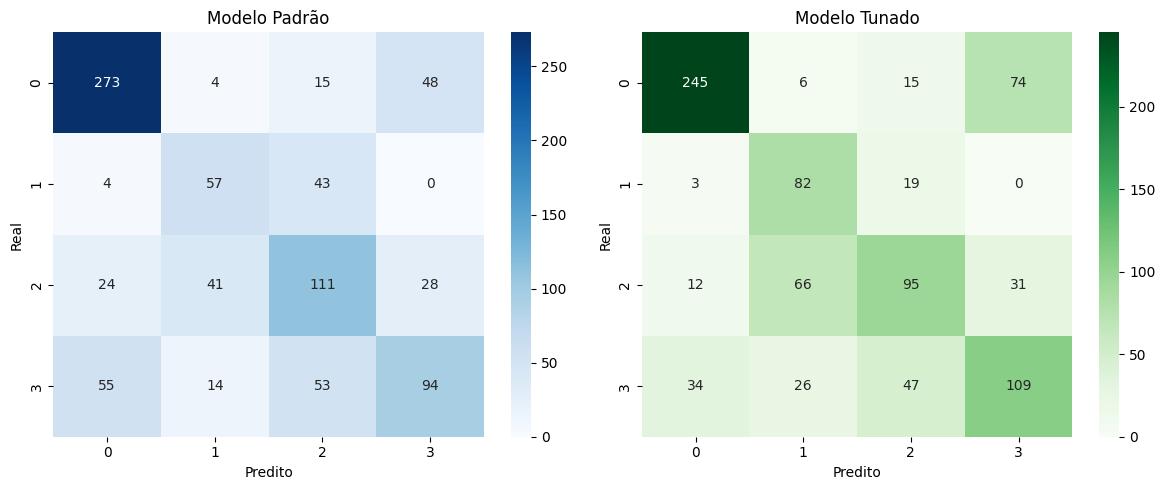

In [38]:
# Matrizes
cm_default = confusion_matrix(y_test, default_pred)
cm_tuned = confusion_matrix(y_test, y_pred)

cm_default = cm_default.astype(int)
cm_tuned = cm_tuned.astype(int)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Modelo padrão 
sns.heatmap(cm_default, 
            annot=True, 
            fmt='d', 
            cmap='Blues', 
            ax=axes[0])

axes[0].set_title('Modelo Padrão')
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Real')

# Modelo tunado 
sns.heatmap(cm_tuned, 
            annot=True, 
            fmt='d', 
            cmap='Greens', 
            ax=axes[1])

axes[1].set_title('Modelo Tunado')
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

# Conclusão: Comparação de Performance dos Modelos

Nesta etapa final, consolidamos os resultados obtidos pelos classificadores treinados para prever a faixa de renda (`income`) dos países. A avaliação baseou-se na capacidade de generalização do modelo vencedor em dados inéditos (conjunto de teste) e na explicabilidade das suas decisões.

#### 1. Resumo dos Resultados

* **Random Forest (Campeão):** Demonstrou uma performance global excelente. A sua natureza de *ensemble* conferiu ao modelo uma robustez ímpar, permitindo capturar os padrões não-lineares complexos nos pilares de dados do Banco Mundial. 
* **Modelos Concorrentes (SVM e Regressão Logística):** Enquanto o SVM conseguiu um desempenho aceitável através de mapeamento não-linear, a Regressão Logística falhou em segmentar corretamente as classes, provando que o desenvolvimento econômico e a infraestrutura de dados não possuem uma relação estritamente linear.

#### 2. Diagnóstico Interpretável (Análise do Modelo Vencedor)

Em vez de apenas olhar para métricas isoladas, a análise do comportamento do **Random Forest** revelou *como* a inteligência artificial está a tomar as suas decisões:

* **Matriz de Confusão (Onde o modelo acerta e erra):** O modelo tem uma facilidade imensa em identificar países de **Alta Renda** e **Renda Média-Alta**. No entanto, o maior desafio ocorre nas faixas mais baixas. O algoritmo frequentemente confunde países de **Renda Baixa** com **Renda Média-Baixa**. Isso reflete a realidade, pois nações em transição econômica partilham características muito semelhantes, dificultando a separação exata.
* **Importância das Variáveis:** A hierarquia de decisão do algoritmo revela que a escala demográfica e o contexto geopolítico desempenham um papel fundamental na classificação econômica. A população do país (`population`) surge como o fator de maior peso, seguida diretamente pelo volume de produtos de dados gerados (`num_data_products`). Além disso, o fato de um país pertencer à região da África Subsaariana (`cat_region_Sub-Saharan Africa`) atua como um divisor de águas crucial para as decisões do modelo. Isso demonstra que a inteligência artificial enxerga o nível de renda como um resultado fortemente atrelado à magnitude populacional e à localização regional, complementados pela capacidade de entrega estatística.
#### 3. Decisão Final

A análise cruzada revelou de forma inquestionável que modelos capazes de lidar com não-linearidades e que oferecem explicabilidade de variáveis são fundamentais para a base do Banco Mundial (*World Bank SPI*). 

**Modelo Selecionado:** O **Random Forest** destaca-se como a melhor escolha absoluta para este problema. Ele não apenas entregou o maior poder preditivo, como transformou o problema em um estudo interpretável sobre como o uso e a produção de produtos de dados são os verdadeiros termômetros da riqueza de uma nação.
